# WFH Burnout — 04: Simplified Model & Interaction Effects

Tests whether a reduced-feature model retains competitive performance, and whether engineered interaction features add predictive value beyond individual features.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER   = ['Low', 'Medium', 'High']
BEHAVIORAL = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
    'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
    'isolation_index'
]
FEATURES = BEHAVIORAL + ['day_type_enc']
print('Libraries loaded')

Libraries loaded


In [2]:
# Load and prepare data
CSV_PATH = 'wfh_burnout_dataset.csv'
df = pd.read_csv(CSV_PATH)
if 'user_id' in df.columns:
    df.drop(columns=['user_id'], inplace=True)
df['day_type_enc'] = (df['day_type'] == 'Weekday').astype(int)

X = df[FEATURES]
y = df['burnout_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES, index=X_test.index)
print(f'Data ready — Train: {X_train.shape}, Test: {X_test.shape}')

Data ready — Train: (1600, 10), Test: (400, 10)


In [3]:
# Top feature sets from notebook 02 consensus ranking
TOP_4 = ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours']
TOP_3 = TOP_4[:3]
TOP_5 = TOP_4 + ['app_switches']

print('Top 3:', TOP_3)
print('Top 4:', TOP_4)
print('Top 5:', TOP_5)

Top 3: ['isolation_index', 'sleep_hours', 'work_hours']
Top 4: ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours']
Top 5: ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours', 'app_switches']


In [4]:
# Full model baseline — all 10 features, 5-fold cross-validated ROC-AUC
rf_full       = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
cv_full       = cross_val_score(rf_full, X_train_scaled, y_train, cv=5, scoring='roc_auc_ovr')
rf_full.fit(X_train_scaled, y_train)
y_proba_full  = rf_full.predict_proba(X_test_scaled)
auc_full      = roc_auc_score(y_test, y_proba_full, multi_class='ovr')

print('=== Full Model (all 10 features) ===')
print(classification_report(y_test, rf_full.predict(X_test_scaled)))
print(f'CV ROC-AUC (5-fold): {cv_full.mean():.4f} ± {cv_full.std():.4f}')
print(f'Test ROC-AUC       : {auc_full:.4f}')

=== Full Model (all 10 features) ===
              precision    recall  f1-score   support

        High       0.84      0.78      0.81        27
         Low       0.95      0.91      0.93       204
      Medium       0.87      0.92      0.89       169

    accuracy                           0.91       400
   macro avg       0.89      0.87      0.88       400
weighted avg       0.91      0.91      0.91       400

CV ROC-AUC (5-fold): 0.9842 ± 0.0035
Test ROC-AUC       : 0.9832


In [5]:
# Simplified models — top 3, 4, 5 features vs full baseline
simplified_results = [{'Model': 'Full (10 features)', 'Features': 10,
                        'CV AUC Mean': cv_full.mean(), 'CV AUC Std': cv_full.std(),
                        'Test AUC': auc_full}]
simplified_models = {}
simplified_probas = {}
rf_params = dict(n_estimators=200, class_weight='balanced', random_state=42)

for label, feature_set in [('Top 3', TOP_3), ('Top 4', TOP_4), ('Top 5', TOP_5)]:
    X_tr     = X_train_scaled[feature_set]
    X_te     = X_test_scaled[feature_set]
    rf       = RandomForestClassifier(**rf_params)
    cv       = cross_val_score(rf, X_tr, y_train, cv=5, scoring='roc_auc_ovr')
    rf.fit(X_tr, y_train)
    proba    = rf.predict_proba(X_te)
    test_auc = roc_auc_score(y_test, proba, multi_class='ovr')
    simplified_results.append({'Model': f'{label} features ({len(feature_set)})',
                                'Features': len(feature_set), 'CV AUC Mean': cv.mean(),
                                'CV AUC Std': cv.std(), 'Test AUC': test_auc})
    simplified_models[label] = rf
    simplified_probas[label] = proba
    print(f'{label}: CV AUC = {cv.mean():.4f} ± {cv.std():.4f}  |  Test AUC = {test_auc:.4f}')

results_df = pd.DataFrame(simplified_results).round(4)
display(results_df)
results_df.to_csv('simplified_model_results.csv', index=False)

Top 3: CV AUC = 0.9855 ± 0.0023  |  Test AUC = 0.9837
Top 4: CV AUC = 0.9845 ± 0.0032  |  Test AUC = 0.9811
Top 5: CV AUC = 0.9860 ± 0.0029  |  Test AUC = 0.9825


,Model,Features,CV AUC Mean,CV AUC Std,Test AUC
0,Full (10 features),10,0.9842,0.0035,0.9832
1,Top 3 features (3),3,0.9855,0.0023,0.9837
2,Top 4 features (4),4,0.9845,0.0032,0.9811
3,Top 5 features (5),5,0.9860,0.0029,0.9825


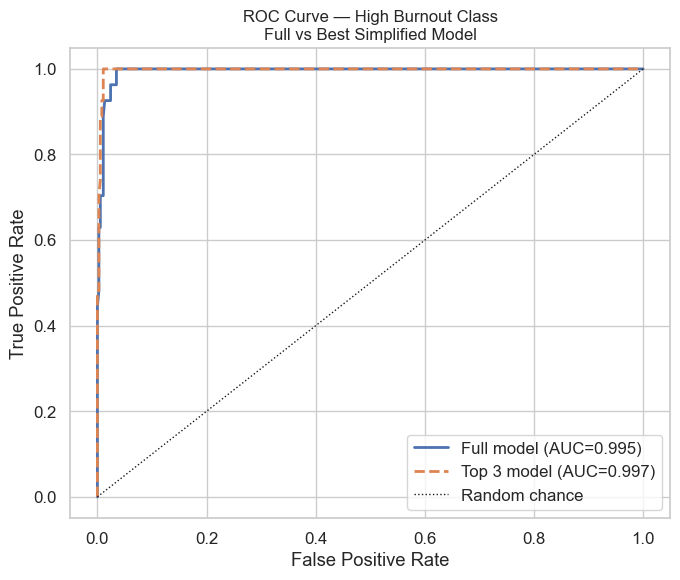

Saved: fig_10_roc_comparison.png


In [6]:
# ROC curve — full model vs best simplified model on the High burnout class
y_test_bin = label_binarize(y_test, classes=ORDER)
high_idx   = 2

fig, ax = plt.subplots(figsize=(7, 6))
full_idx_map = {cls: i for i, cls in enumerate(rf_full.classes_)}
fpr_f, tpr_f, _ = roc_curve(y_test_bin[:, high_idx],
                              y_proba_full[:, full_idx_map['High']])
ax.plot(fpr_f, tpr_f, label=f'Full model (AUC={auc(fpr_f, tpr_f):.3f})', linewidth=2)

best_row   = results_df.iloc[1:].sort_values('Test AUC', ascending=False).iloc[0]
best_label = ' '.join(best_row['Model'].split()[:2])
best_proba = simplified_probas[best_label]
best_model = simplified_models[best_label]
simp_idx_map = {cls: i for i, cls in enumerate(best_model.classes_)}
fpr_s, tpr_s, _ = roc_curve(y_test_bin[:, high_idx],
                              best_proba[:, simp_idx_map['High']])
ax.plot(fpr_s, tpr_s, label=f'{best_label} model (AUC={auc(fpr_s, tpr_s):.3f})',
        linewidth=2, linestyle='--')
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — High Burnout Class\nFull vs Best Simplified Model', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_10_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_10_roc_comparison.png')

In [7]:
# Interaction feature engineering
# Three compound features that capture behavioral co-occurrence effects:
#   overwork_fatigue  = work_hours x (10 - sleep_hours): high when both overworked and sleep-deprived
#   isolated_overwork = isolation_index x work_hours: high when both isolated and overworked
#   no_recovery       = work_hours / (breaks_taken + 1): work-to-rest ratio (+1 avoids divide by zero)
df['overwork_fatigue']  = df['work_hours'] * (10 - df['sleep_hours'])
df['isolated_overwork'] = df['isolation_index'] * df['work_hours']
df['no_recovery']       = df['work_hours'] / (df['breaks_taken'] + 1)

INTERACTION_FEATURES = ['overwork_fatigue', 'isolated_overwork', 'no_recovery']
risk_enc = df['burnout_risk'].map({'Low': 0, 'Medium': 1, 'High': 2})

print('Interaction feature correlations with burnout_risk:')
for feat in INTERACTION_FEATURES:
    print(f'  {feat:25s}: r = {df[feat].corr(risk_enc):.3f}')

Interaction feature correlations with burnout_risk:
  overwork_fatigue         : r = 0.753
  isolated_overwork        : r = 0.821
  no_recovery              : r = 0.431


In [8]:
# Interaction model vs baseline — does adding interaction terms improve performance?
INTERACTION_SET = TOP_4 + INTERACTION_FEATURES
X_int       = df[INTERACTION_SET]
y_int       = df['burnout_risk']
X_int_train, _, y_int_train, _ = train_test_split(
    X_int, y_int, test_size=0.2, random_state=42, stratify=y_int
)
scaler_int     = StandardScaler()
X_int_train_sc = pd.DataFrame(scaler_int.fit_transform(X_int_train),
                               columns=INTERACTION_SET, index=X_int_train.index)

rf_params  = dict(n_estimators=200, class_weight='balanced', random_state=42)
cv_base    = cross_val_score(RandomForestClassifier(**rf_params),
                             X_int_train_sc[TOP_4], y_int_train, cv=5, scoring='roc_auc_ovr')
cv_inter   = cross_val_score(RandomForestClassifier(**rf_params),
                             X_int_train_sc[INTERACTION_SET], y_int_train, cv=5, scoring='roc_auc_ovr')

print('='*55)
print('INTERACTION EFFECT TEST')
print('='*55)
print(f'Baseline  (top 4 features)         CV AUC: {cv_base.mean():.4f} ± {cv_base.std():.4f}')
print(f'Interaction (top 4 + 3 engineered) CV AUC: {cv_inter.mean():.4f} ± {cv_inter.std():.4f}')
delta = cv_inter.mean() - cv_base.mean()
print(f'Delta: {delta:+.4f}')
if   delta >  0.005: print('Interaction features IMPROVE performance')
elif delta < -0.005: print('Interaction features HURT performance')
else:                print('Interaction features make NO meaningful difference')
print('='*55)

INTERACTION EFFECT TEST
Baseline  (top 4 features)         CV AUC: 0.9845 ± 0.0032
Interaction (top 4 + 3 engineered) CV AUC: 0.9873 ± 0.0028
Delta: +0.0028
Interaction features make NO meaningful difference


In [9]:
# Final project summary
print('='*65)
print('PROJECT SUMMARY')
print('='*65)
print(f'Records: {len(df)}  |  Features: {len(BEHAVIORAL)}  |  Classes: Low/Medium/High')
print(f'\nTop 4 features (consensus): {TOP_4}')
print(f'\nFull model Test AUC : {auc_full:.4f}')
best = results_df.iloc[1:].sort_values('Test AUC', ascending=False).iloc[0]
print(f'Best simplified AUC : {best["Test AUC"]:.4f}  ({best["Model"]})')
print(f'Interaction delta   : {cv_inter.mean() - cv_base.mean():+.4f}')
print('='*65)

PROJECT SUMMARY
Records: 2000  |  Features: 9  |  Classes: Low/Medium/High

Top 4 features (consensus): ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours']

Full model Test AUC : 0.9832
Best simplified AUC : 0.9837  (Top 3 features (3))
Interaction delta   : +0.0028
